In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ifean\Downloads\TechCrush\hotel_bookings_cleaned.csv")

In [3]:
df.shape

(87396, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,81.004657,11.016809,0.749565,106.337392,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,109.945638,54.047484,10.015731,55.013671,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
# We need to inspect the entire column to check if the data is actually duplicated.
pd.set_option("display.max_columns", None)

In [8]:
df['children'] = df['children'].astype('int64')

In [9]:
# Convert the reservation_status_date to DATE format
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87396 non-null  object        
 1   is_canceled                     87396 non-null  int64         
 2   lead_time                       87396 non-null  int64         
 3   arrival_date_year               87396 non-null  int64         
 4   arrival_date_month              87396 non-null  object        
 5   arrival_date_week_number        87396 non-null  int64         
 6   arrival_date_day_of_month       87396 non-null  int64         
 7   stays_in_weekend_nights         87396 non-null  int64         
 8   stays_in_week_nights            87396 non-null  int64         
 9   adults                          87396 non-null  int64         
 10  children                        87396 non-null  int64         
 11  ba

In [11]:
df[df['adults']==0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2088,Resort Hotel,0,1,2015,October,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2224,Resort Hotel,0,0,2015,October,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
2804,Resort Hotel,0,36,2015,November,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3091,Resort Hotel,0,165,2015,December,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3099,Resort Hotel,0,165,2015,December,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85536,City Hotel,0,296,2017,July,30,27,1,3,0,2,0,BB,GBR,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0.0,0,Transient,98.85,0,1,Check-Out,2017-07-31
85595,City Hotel,0,276,2017,July,31,30,2,1,0,2,0,BB,DEU,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,9.0,0.0,0,Transient,93.64,0,2,Check-Out,2017-08-02
85622,City Hotel,0,291,2017,July,30,29,2,2,0,2,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0.0,0,Transient,98.85,0,1,Check-Out,2017-08-02
85747,City Hotel,0,159,2017,July,31,31,1,3,0,2,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,9.0,0.0,0,Transient,121.88,0,1,Check-Out,2017-08-04


In [12]:
df[(df['adults']==0) & (df['children']>0)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
34444,City Hotel,0,1,2015,August,33,10,1,1,0,3,0,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,0.0,0.0,0,Transient-Party,9.00,0,0,Check-Out,2015-08-12
34502,City Hotel,0,104,2015,August,33,11,0,3,0,2,0,BB,FRA,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,7.0,0.0,0,Transient-Party,6.00,0,2,Check-Out,2015-08-14
34670,City Hotel,0,3,2015,August,34,16,2,0,0,2,0,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,0.0,0.0,0,Transient-Party,6.00,0,1,Check-Out,2015-08-18
35032,City Hotel,0,15,2015,August,35,28,0,1,0,2,0,BB,PRT,Complementary,Direct,0,0,0,B,B,0,No Deposit,0.0,45.0,0,Transient,0.00,0,1,Check-Out,2015-08-29
36578,City Hotel,1,48,2015,October,43,19,1,3,0,2,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,B,B,0,No Deposit,13.0,0.0,0,Transient-Party,6.00,0,1,Canceled,2015-09-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85536,City Hotel,0,296,2017,July,30,27,1,3,0,2,0,BB,GBR,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0.0,0,Transient,98.85,0,1,Check-Out,2017-07-31
85595,City Hotel,0,276,2017,July,31,30,2,1,0,2,0,BB,DEU,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,9.0,0.0,0,Transient,93.64,0,2,Check-Out,2017-08-02
85622,City Hotel,0,291,2017,July,30,29,2,2,0,2,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0.0,0,Transient,98.85,0,1,Check-Out,2017-08-02
85747,City Hotel,0,159,2017,July,31,31,1,3,0,2,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,9.0,0.0,0,Transient,121.88,0,1,Check-Out,2017-08-04


In [13]:
df[(df['adults']==0) & (df['children']>1)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
34444,City Hotel,0,1,2015,August,33,10,1,1,0,3,0,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,0.0,0.0,0,Transient-Party,9.00,0,0,Check-Out,2015-08-12
34502,City Hotel,0,104,2015,August,33,11,0,3,0,2,0,BB,FRA,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,7.0,0.0,0,Transient-Party,6.00,0,2,Check-Out,2015-08-14
34670,City Hotel,0,3,2015,August,34,16,2,0,0,2,0,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,0.0,0.0,0,Transient-Party,6.00,0,1,Check-Out,2015-08-18
35032,City Hotel,0,15,2015,August,35,28,0,1,0,2,0,BB,PRT,Complementary,Direct,0,0,0,B,B,0,No Deposit,0.0,45.0,0,Transient,0.00,0,1,Check-Out,2015-08-29
36578,City Hotel,1,48,2015,October,43,19,1,3,0,2,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,B,B,0,No Deposit,13.0,0.0,0,Transient-Party,6.00,0,1,Canceled,2015-09-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85536,City Hotel,0,296,2017,July,30,27,1,3,0,2,0,BB,GBR,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0.0,0,Transient,98.85,0,1,Check-Out,2017-07-31
85595,City Hotel,0,276,2017,July,31,30,2,1,0,2,0,BB,DEU,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,9.0,0.0,0,Transient,93.64,0,2,Check-Out,2017-08-02
85622,City Hotel,0,291,2017,July,30,29,2,2,0,2,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0.0,0,Transient,98.85,0,1,Check-Out,2017-08-02
85747,City Hotel,0,159,2017,July,31,31,1,3,0,2,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,9.0,0.0,0,Transient,121.88,0,1,Check-Out,2017-08-04


In [14]:
df[(df['adults']==0) & (df['babies']>0)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
36964,City Hotel,0,6,2015,December,51,18,0,1,0,2,1,BB,PRT,Online TA,TA/TO,0,0,0,B,B,0,No Deposit,9.0,0.0,0,Transient-Party,77.00,0,2,Check-Out,2015-12-19
56203,City Hotel,1,22,2015,December,50,9,1,4,0,2,1,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,14.0,0.0,0,Transient,80.75,0,1,No-Show,2015-12-09
63468,City Hotel,0,14,2016,June,24,9,0,3,0,2,1,BB,ITA,Online TA,TA/TO,0,0,0,B,B,2,No Deposit,9.0,0.0,0,Transient,116.49,0,2,Check-Out,2016-06-12


In [15]:
# Feature engineering 
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['booking_value'] = df['adr'] * df['total_nights'] #This represents the estimated total room-booking economic value, not necessarily the total hotel revenue

In [16]:
df[df['total_guests'] == 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,booking_value
2088,Resort Hotel,0,1,2015,October,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06,0,3,0.00
2224,Resort Hotel,0,0,2015,October,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12,0,0,0.00
2804,Resort Hotel,0,36,2015,November,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23,0,3,0.00
3091,Resort Hotel,0,165,2015,December,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04,0,5,0.00
3099,Resort Hotel,0,165,2015,December,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05,0,6,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83728,City Hotel,0,107,2017,June,26,27,0,3,0,0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7.0,0.0,0,Transient,100.80,0,0,Check-Out,2017-06-30,0,3,302.40
83780,City Hotel,0,1,2017,June,26,30,0,1,0,0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0.0,0.0,0,Transient,0.00,1,1,Check-Out,2017-07-01,0,1,0.00
84714,City Hotel,0,44,2017,July,28,15,1,1,0,0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425.0,0.0,0,Transient,73.80,0,0,Check-Out,2017-07-17,0,2,147.60
84970,City Hotel,0,2,2017,July,28,15,2,5,0,0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9.0,0.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22,0,7,160.02


In [17]:
condition = (df['total_guests'] == 0) & (df['is_canceled'] == 0) & (df['reservation_status'] == 'Check-Out')
df[condition]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,booking_value
2088,Resort Hotel,0,1,2015,October,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06,0,3,0.00
2224,Resort Hotel,0,0,2015,October,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12,0,0,0.00
2804,Resort Hotel,0,36,2015,November,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23,0,3,0.00
3091,Resort Hotel,0,165,2015,December,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04,0,5,0.00
3099,Resort Hotel,0,165,2015,December,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05,0,6,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83728,City Hotel,0,107,2017,June,26,27,0,3,0,0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7.0,0.0,0,Transient,100.80,0,0,Check-Out,2017-06-30,0,3,302.40
83780,City Hotel,0,1,2017,June,26,30,0,1,0,0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0.0,0.0,0,Transient,0.00,1,1,Check-Out,2017-07-01,0,1,0.00
84714,City Hotel,0,44,2017,July,28,15,1,1,0,0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425.0,0.0,0,Transient,73.80,0,0,Check-Out,2017-07-17,0,2,147.60
84970,City Hotel,0,2,2017,July,28,15,2,5,0,0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9.0,0.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22,0,7,160.02


In [18]:
df[condition][[
    'hotel',
    'adr',
    'stays_in_week_nights',
    'stays_in_weekend_nights',
    'reservation_status'
]]

,hotel,adr,stays_in_week_nights,stays_in_weekend_nights,reservation_status
2088,Resort Hotel,0.00,3,0,Check-Out
2224,Resort Hotel,0.00,0,0,Check-Out
2804,Resort Hotel,0.00,2,1,Check-Out
3091,Resort Hotel,0.00,4,1,Check-Out
3099,Resort Hotel,0.00,4,2,Check-Out
...,...,...,...,...,...
83728,City Hotel,100.80,3,0,Check-Out
83780,City Hotel,0.00,1,0,Check-Out
84714,City Hotel,73.80,1,1,Check-Out
84970,City Hotel,22.86,5,2,Check-Out


In [19]:
df[condition].shape[0]

150

In [20]:
df[condition]['hotel'].value_counts()

hotel
City Hotel      140
Resort Hotel     10
Name: count, dtype: int64

In [21]:
df[condition]['booking_value'].describe()

count    150.000000
mean      62.321200
std      157.184342
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      818.760000
Name: booking_value, dtype: float64

**150 records (0.17% of the dataset) contained zero guests despite having a completed reservation status ('Check-Out'). These records were considered inconsistent and removed from the analysis.**

In [22]:
new_df = df[~condition].copy()

In [23]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87246 entries, 0 to 87395
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87246 non-null  object        
 1   is_canceled                     87246 non-null  int64         
 2   lead_time                       87246 non-null  int64         
 3   arrival_date_year               87246 non-null  int64         
 4   arrival_date_month              87246 non-null  object        
 5   arrival_date_week_number        87246 non-null  int64         
 6   arrival_date_day_of_month       87246 non-null  int64         
 7   stays_in_weekend_nights         87246 non-null  int64         
 8   stays_in_week_nights            87246 non-null  int64         
 9   adults                          87246 non-null  int64         
 10  children                        87246 non-null  int64         
 11  babies 

In [24]:
months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

new_df['arrival_date_month'] = pd.Categorical(
    new_df['arrival_date_month'],
    categories=months,
    ordered=True
)

In [25]:
hotel_palette = {
    'City Hotel': '#1f77b4',     # Blue
    'Resort Hotel': '#ff7f0e'    # Orange
}

# 1. Understanding Revenue Performance

## 1.1 Distribution of ADR

**Business Questions:**

- *How is room pricing distributed across hotel bookings?*
- *How does pricing differ between Resort and City hotels?*

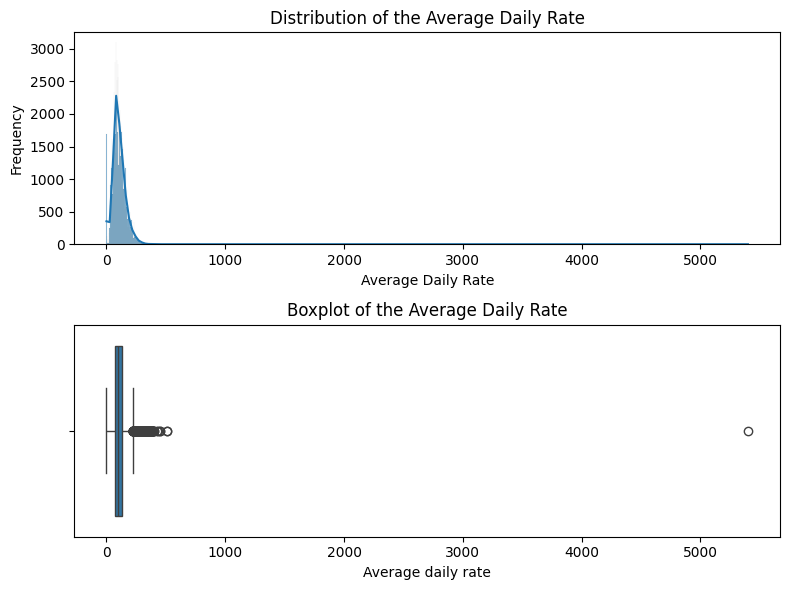

In [26]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
sns.histplot(new_df['adr'], edgecolor='black', kde=True)
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")
plt.title("Distribution of the Average Daily Rate")

plt.subplot(2,1,2)
sns.boxplot(x=new_df['adr'])
plt.title("Boxplot of the Average Daily Rate")
plt.xlabel("Average daily rate")

plt.tight_layout()
plt.show()

In [27]:
new_df[new_df['adr'] >= 1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,booking_value
38749,City Hotel,1,35,2016,March,13,25,0,1,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,0.0,0,Transient,5400.0,0,0,Canceled,2016-02-19,2,1,5400.0


**Note:** We can see that we have a sole outlier that needs to be removed

Check the booking value distributionas well

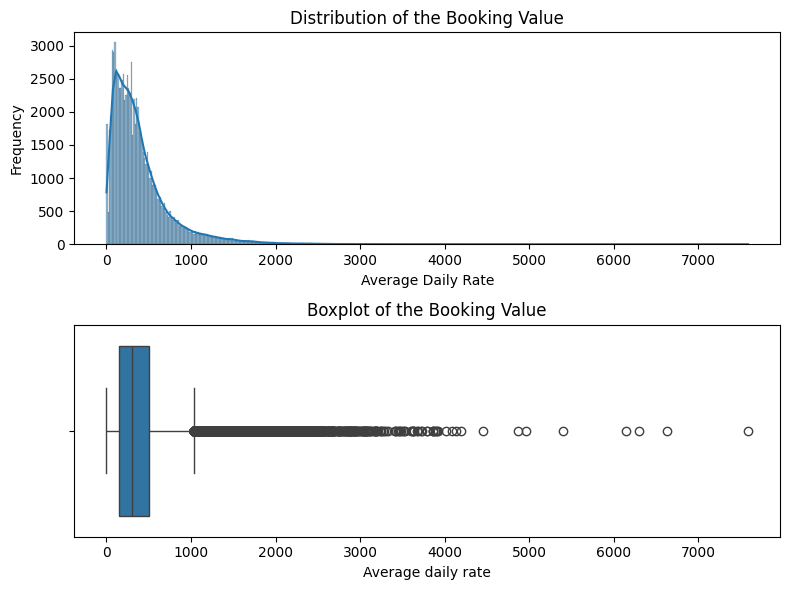

In [28]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
sns.histplot(new_df['booking_value'], edgecolor='black', kde=True)
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")
plt.title("Distribution of the Booking Value")

plt.subplot(2,1,2)
sns.boxplot(x=new_df['booking_value'])
plt.title("Boxplot of the Booking Value")
plt.xlabel("Average daily rate")

plt.tight_layout()
plt.show()

In [29]:
new_df[new_df['booking_value'] >= 6000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,booking_value
9984,Resort Hotel,1,378,2017,August,31,1,4,10,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314.0,0.0,0,Transient,450.0,0,0,Canceled,2016-07-22,2,14,6300.0
10825,Resort Hotel,0,113,2015,August,31,1,18,42,1,0,0,HB,Unknown,Direct,Direct,0,0,0,E,E,0,No Deposit,0.0,0.0,0,Transient,110.5,0,3,Check-Out,2015-09-30,1,60,6630.0
10826,Resort Hotel,0,126,2016,July,28,5,19,50,1,0,0,HB,Unknown,Direct,Direct,0,0,1,E,E,2,No Deposit,0.0,0.0,0,Transient,110.0,0,3,Check-Out,2016-09-12,1,69,7590.0
44707,City Hotel,1,16,2016,November,45,5,8,21,1,1,0,BB,AGO,Direct,Direct,0,0,0,G,G,0,No Deposit,14.0,0.0,0,Transient,212.0,0,0,Canceled,2016-10-20,2,29,6148.0


**NOTE:** We'll filter outliers based on the "adr" rather than "booking_value" because the latter is a derived/engineered feature. 

In [30]:
new_df = new_df[new_df['adr'] <= 1000]

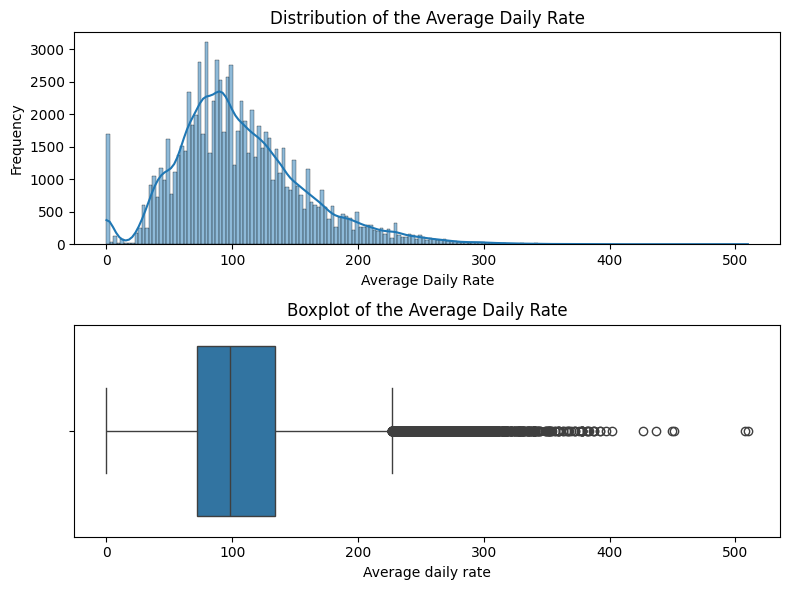

In [31]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
sns.histplot(new_df['adr'], edgecolor='black', kde=True)
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")
plt.title("Distribution of the Average Daily Rate")

plt.subplot(2,1,2)
sns.boxplot(x=new_df['adr'])
plt.title("Boxplot of the Average Daily Rate")
plt.xlabel("Average daily rate")

plt.tight_layout()
plt.show()

**Note:** From this, we can see that we still have lots of outliers. ADR exhibits a right-skewed distribution, indicating that while most bookings are moderately priced, a significant proportion of bookings may represent premium/high-value stays.

Text(0.5, 1.0, 'Pricing Distribution between Hotels')

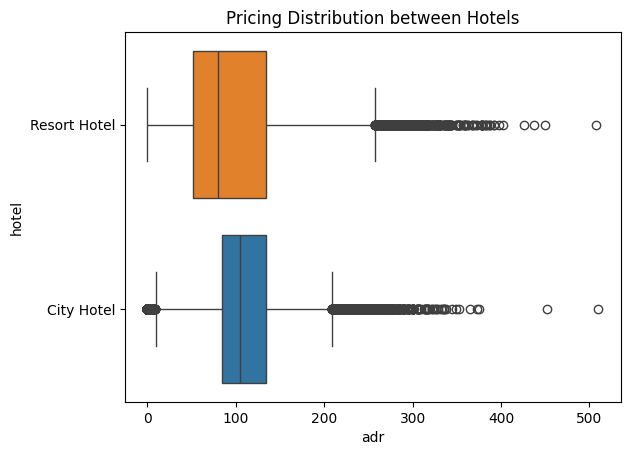

In [32]:
sns.boxplot(
    data=new_df,
    x='adr',
    y='hotel',
    hue='hotel',
    palette=hotel_palette
)
plt.title("Pricing Distribution between Hotels")

**Insight:** City Hotel appears to have a higher median, suggesting higher typical pricing, while Resort Hotel exhibits a greater spread, suggesting greater pricing variability and some of the highest premium bookings.

In [33]:
# Set threshold to remove outliers a bit more
min_thresold, max_thresold = df['adr'].quantile([0.0001, 0.9999])
min_thresold, max_thresold

(0.0, 393.401489999943)

In [34]:
new_df[new_df['adr']>=390]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,booking_value
9984,Resort Hotel,1,378,2017,August,31,1,4,10,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314.0,0.0,0,Transient,450.00,0,0,Canceled,2016-07-22,2,14,6300.00
10150,Resort Hotel,1,116,2017,August,32,9,2,8,2,1,0,HB,PRT,Direct,Direct,0,0,0,F,F,3,No Deposit,250.0,0.0,0,Transient,392.00,0,0,Canceled,2017-04-17,3,10,3920.00
10214,Resort Hotel,1,59,2017,August,33,13,2,4,2,2,0,FB,PRT,Direct,Direct,0,0,0,H,H,1,No Deposit,250.0,0.0,0,Transient,437.00,0,0,Canceled,2017-08-03,4,6,2622.00
11661,Resort Hotel,0,1,2015,July,29,15,0,1,2,0,0,BB,PRT,Corporate,Corporate,1,0,1,A,C,0,No Deposit,0.0,0.0,0,Transient,508.00,1,0,Check-Out,2015-07-16,2,1,508.00
33056,Resort Hotel,0,26,2017,July,31,31,3,5,3,2,0,HB,MAR,Direct,Direct,0,0,0,H,H,1,No Deposit,250.0,0.0,0,Transient,397.38,0,1,Check-Out,2017-08-08,5,8,3179.04
33093,Resort Hotel,0,31,2017,August,31,1,2,6,2,2,0,Undefined,PRT,Direct,Direct,0,0,0,G,G,0,No Deposit,250.0,0.0,0,Transient,426.25,0,2,Check-Out,2017-08-09,4,8,3410.00
33438,Resort Hotel,0,24,2017,August,33,17,0,3,2,0,0,HB,PRT,Online TA,TA/TO,0,0,0,G,G,1,No Deposit,240.0,0.0,0,Transient,392.00,1,1,Check-Out,2017-08-20,2,3,1176.00
33489,Resort Hotel,0,104,2017,August,33,17,2,3,3,1,0,HB,ESP,Online TA,TA/TO,0,0,0,H,H,2,No Deposit,240.0,0.0,0,Transient,402.00,0,1,Check-Out,2017-08-22,4,5,2010.00
74461,City Hotel,0,81,2016,December,53,31,1,1,2,2,0,BB,PRT,Direct,Direct,0,0,0,E,E,1,No Deposit,0.0,0.0,0,Transient-Party,451.50,0,4,Check-Out,2017-01-02,4,2,903.00
80728,City Hotel,0,0,2017,May,19,9,0,1,1,0,0,BB,ITA,Offline TA/TO,TA/TO,0,0,0,A,G,0,No Deposit,159.0,0.0,0,Transient,510.00,0,0,Check-Out,2017-05-10,1,1,510.00


In [35]:
# We filter off the values outside the threshold
new_df = new_df[(new_df['adr'] <= max_thresold) & (new_df['adr'] >= min_thresold)]
new_df.shape

(87237, 35)

In [36]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87237 entries, 0 to 87395
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87237 non-null  object        
 1   is_canceled                     87237 non-null  int64         
 2   lead_time                       87237 non-null  int64         
 3   arrival_date_year               87237 non-null  int64         
 4   arrival_date_month              87237 non-null  category      
 5   arrival_date_week_number        87237 non-null  int64         
 6   arrival_date_day_of_month       87237 non-null  int64         
 7   stays_in_weekend_nights         87237 non-null  int64         
 8   stays_in_week_nights            87237 non-null  int64         
 9   adults                          87237 non-null  int64         
 10  children                        87237 non-null  int64         
 11  babies 

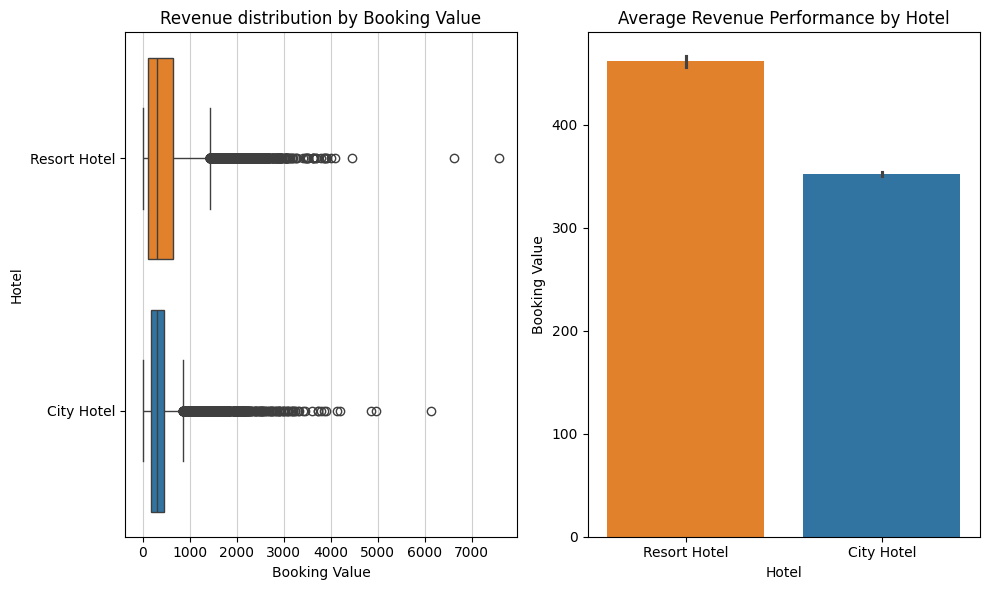

In [37]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.boxplot(
    data=new_df,
    x='booking_value',
    y='hotel',
    hue='hotel',
    palette=hotel_palette
)
plt.xlabel("Booking Value")
plt.ylabel("Hotel")
plt.title("Revenue distribution by Booking Value")
plt.grid(axis='x', alpha=0.6)

plt.subplot(1,2,2)
sns.barplot(
    data=new_df,
    x='hotel',
    y='booking_value',
    hue='hotel',
    palette=hotel_palette
)
plt.xlabel("Hotel")
plt.ylabel("Booking Value")
plt.title("Average Revenue Performance by Hotel")

plt.tight_layout()
plt.show()

# 1.2 Seasonal Booking Revenue Analysis

**Business Question**
- *Which seasons generate high revenue performance from booking?*
- *Which seasons have high booking demand?*

In [38]:
# plt.figure(figsize=(10,6))
# sns.barplot(
#     data=new_df,
#     x='arrival_date_month',
#     y='booking_value',
#     hue='hotel',
#     order=months
# )
# plt.xlabel("Months")
# plt.ylabel("Booking Value")
# plt.title("Booking Value by Month")
# plt.tight_layout()
# plt.show()

In [39]:
monthly_revenue = (
    new_df
    .groupby(['arrival_date_month', 'hotel'])['booking_value']
    .sum()
    .reset_index()
)
monthly_revenue

C:\Users\ifean\AppData\Local\Temp\ipykernel_32468\1529002931.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['arrival_date_month', 'hotel'])['booking_value']


,arrival_date_month,hotel,booking_value
0,January,City Hotel,789794.89
1,January,Resort Hotel,289414.97
2,February,City Hotel,1034537.94
3,February,Resort Hotel,438187.49
4,March,City Hotel,1446155.80
5,March,Resort Hotel,596880.89
6,April,City Hotel,1893471.88
7,April,Resort Hotel,892866.41
8,May,City Hotel,2058535.15
9,May,Resort Hotel,1063202.63


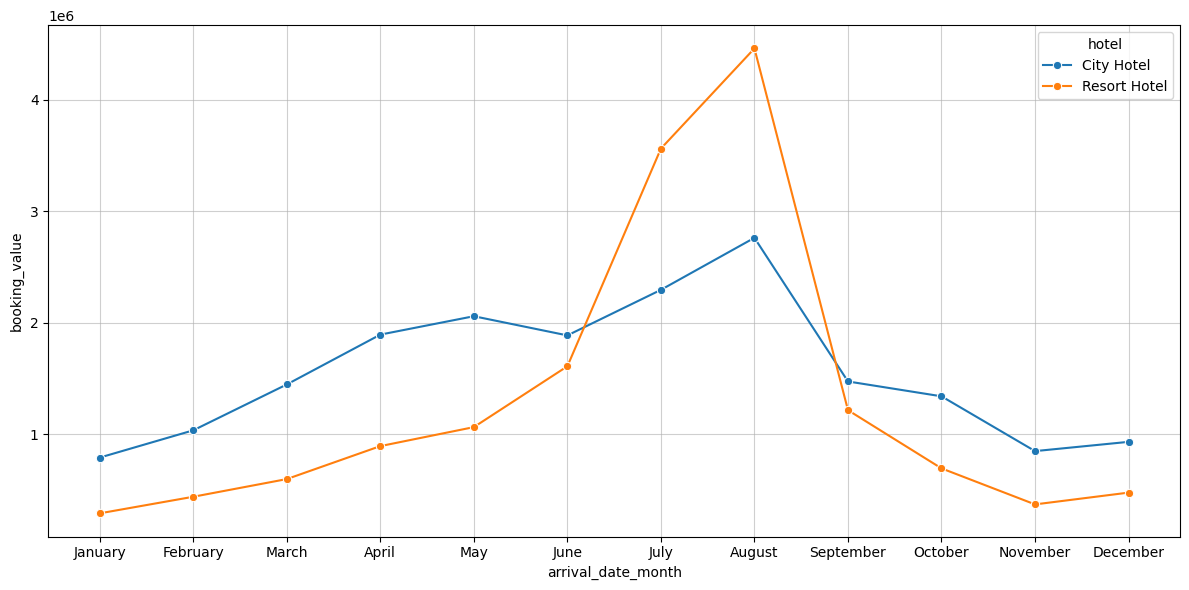

In [40]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_revenue,
    x='arrival_date_month',
    y='booking_value',
    hue='hotel',
    marker='o',
    palette=hotel_palette
)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

In [41]:
monthly_bookings = new_df.groupby(['arrival_date_month', 'hotel']).size().reset_index(name='booking_count')
monthly_bookings

C:\Users\ifean\AppData\Local\Temp\ipykernel_32468\1814879483.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bookings = new_df.groupby(['arrival_date_month', 'hotel']).size().reset_index(name='booking_count')


,arrival_date_month,hotel,booking_count
0,January,City Hotel,2725
1,January,Resort Hotel,1961
2,February,City Hotel,3593
3,February,Resort Hotel,2493
4,March,City Hotel,4833
5,March,Resort Hotel,2656
6,April,City Hotel,5075
7,April,Resort Hotel,2828
8,May,City Hotel,5401
9,May,Resort Hotel,2942


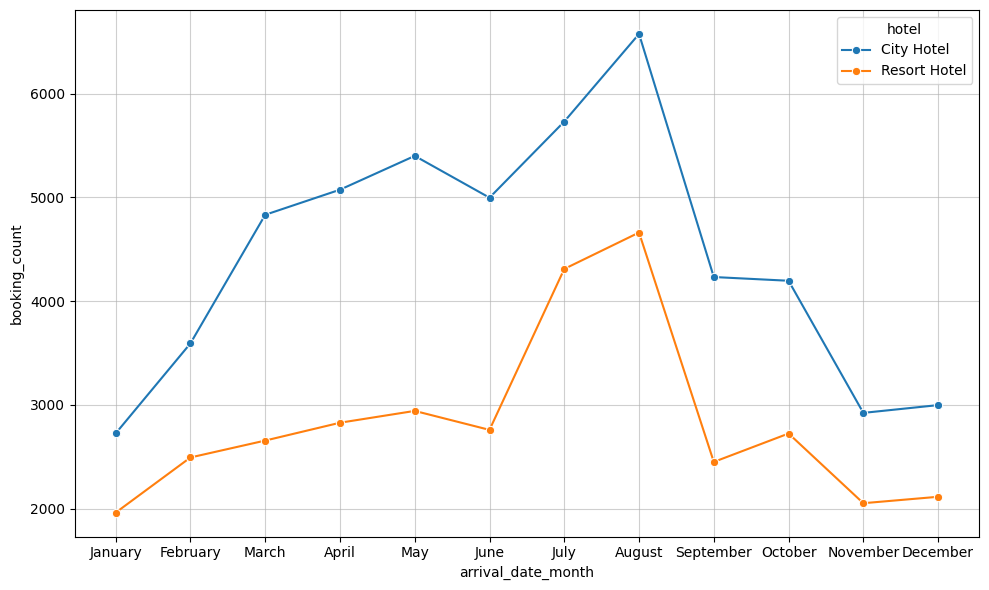

In [42]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=monthly_bookings,
    x='arrival_date_month',
    y='booking_count',
    hue='hotel',
    marker='o',
    palette=hotel_palette
)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

**Insight:** The hotel industry exhibits a strong seasonal pattern, with both booking demand and booking value peaking in July and August, which typically coincide with the summer vacation period. While City Hotels generally record higher booking volumes and stronger revenue performance during most months of the year, Resort Hotels significantly outperform City Hotels during the peak summer months in terms of booking value. This suggests that guests are more likely to book higher-priced accommodations and stay for longer durations at Resort Hotels during these periods. Consequently, the surge in booking value during the peak season is likely driven by a combination of premium room bookings and extended lengths of stay.

## 1.3 Market Segment Analysis

**Business Question**

- *Which customer markets contribute the most economically?*

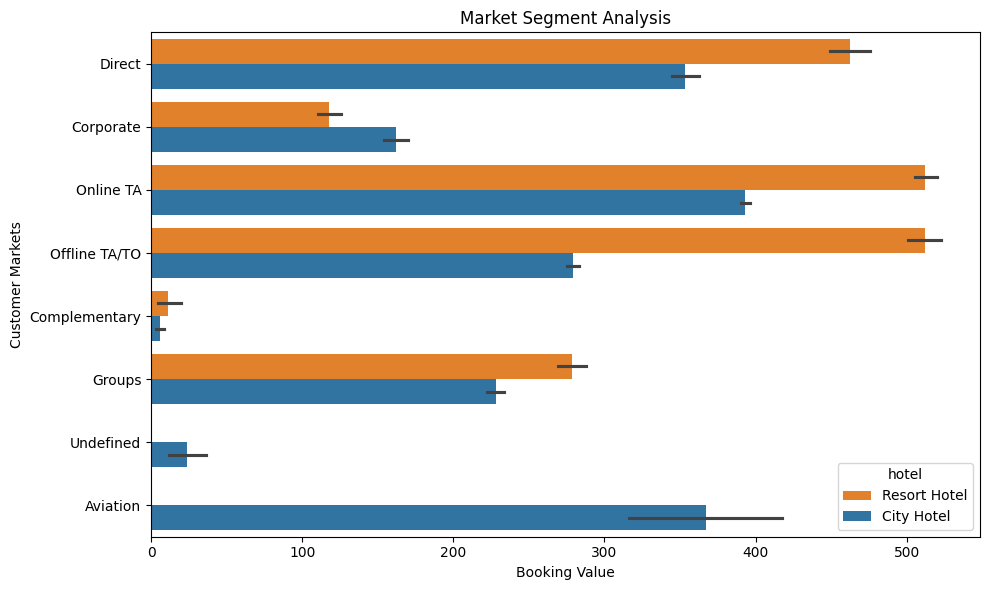

In [57]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=new_df,
    y='market_segment',
    x='booking_value',
    hue='hotel',
    palette=hotel_palette
)
plt.ylabel("Customer Markets")
plt.xlabel("Booking Value")
plt.title("Market Segment Analysis")

plt.tight_layout()
plt.show()

**Insight:**
- Online TA and Offline TA/TO segments generate the highest booking values for Resort Hotels (both above ≈500), making travel intermediaries a major revenue driver.
- Direct bookings also produce strong booking values in both hotel types, with Resort Hotels outperforming City Hotels.
- In City Hotels, Online TA, Aviation, and Direct segments are among the highest-value contributors.

## 1.4 Customer Type Analysis

**Business Question**
- *Which customer structures generate the highest booking value?*

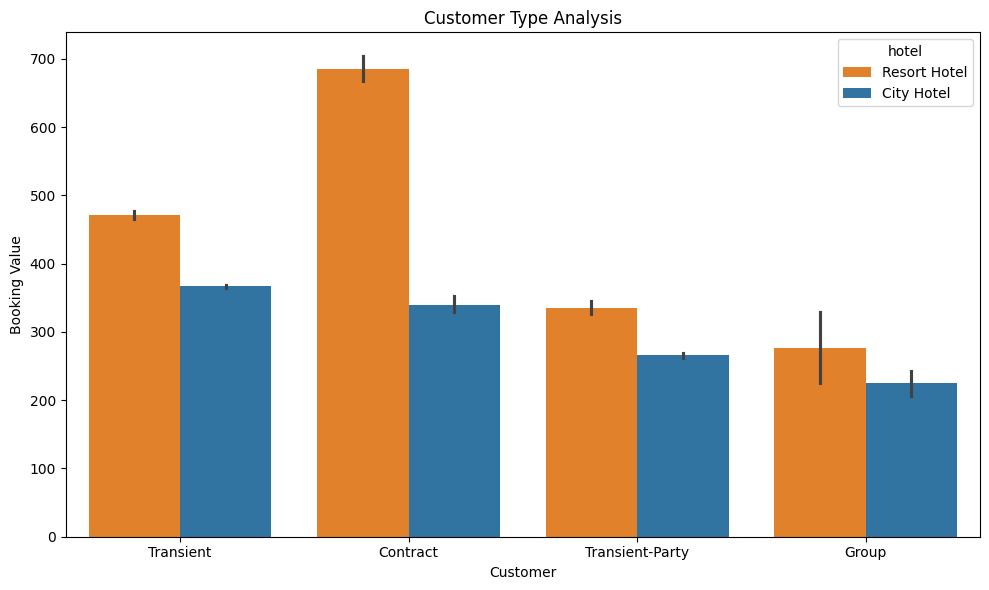

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=new_df,
    x='customer_type',
    y='booking_value',
    hue='hotel',
    palette=hotel_palette
)
plt.xlabel("Customer")
plt.ylabel("Booking Value")
plt.title("Customer Type Analysis")

plt.tight_layout()
plt.show()

**Insight:**
- Contract customers generate the highest booking value in Resort Hotels, substantially outperforming all other customer types.
- In City Hotels, Transient customers contribute the highest booking value, slightly ahead of Contract customers.
- Across all customer types, Resort Hotels consistently generate higher booking values than City Hotels, indicating that leisure-oriented stays tend to be more valuable.

# 2. Understanding Customer Behaviour

## 2.1 Deposit Type Analysis

**Business Question**
- *How do customers like to pay?*

<Axes: xlabel='deposit_type', ylabel='count'>

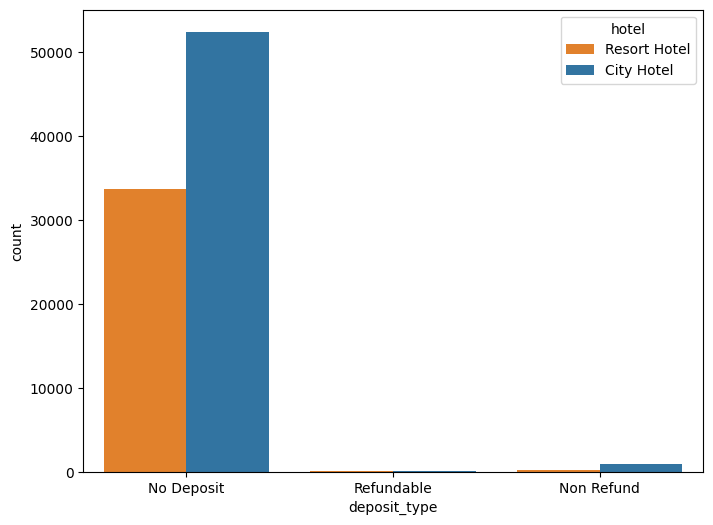

In [45]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=new_df,
    x='deposit_type',
    hue='hotel',
    palette=hotel_palette
)

**Insight: Most customers prefer to pay upfront when they arrive the hotel than to deposit money prior to arrival**

## 2.2 Hotel Type Analysis

**Business Question**
- *Which hotel do customers frequent more?*

C:\Users\ifean\AppData\Local\Temp\ipykernel_32468\284100709.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='hotel', ylabel='count'>

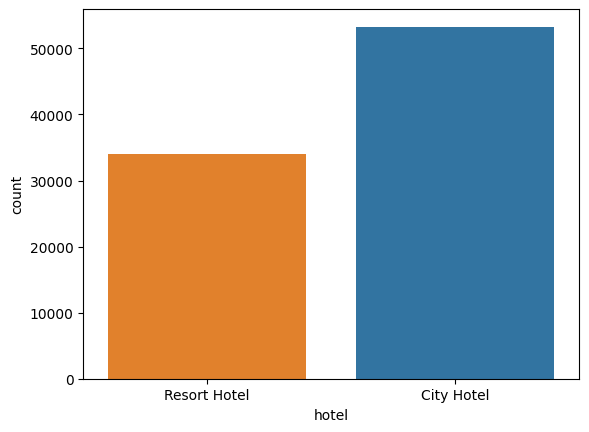

In [46]:
sns.countplot(
    data=new_df,
    x='hotel',
    palette=hotel_palette
)

## 2.3 Repeat Guest Behaviour

**Business Question**
- *Do loyal customers contribute more economically?*

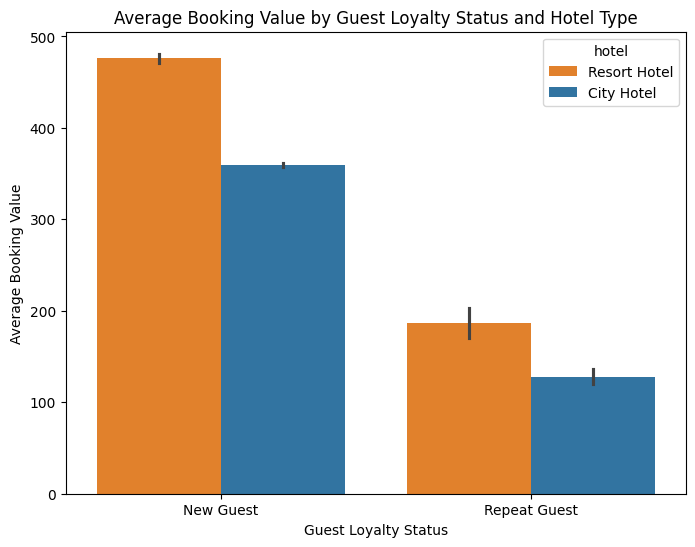

In [47]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=new_df,
    x='is_repeated_guest',
    y='booking_value',
    hue='hotel',
    palette=hotel_palette
)

plt.xticks([0,1], ['New Guest', 'Repeat Guest'])

plt.xlabel('Guest Loyalty Status')
plt.ylabel('Average Booking Value')
plt.title('Average Booking Value by Guest Loyalty Status and Hotel Type')

plt.show()

**Insight: Loyal guests do not drive the bulk of the hotel's economic value. The hotels attract new customers steadily and the economic value of the hotels are boosted by these new customers seeking new experiences**

## 2.4 Booking Outcome Analysis

**Business Question**
- *What proportion of bookings were honored versus canceled across the two hotel types?*

In [48]:
new_df['booking_outcome'] = new_df['is_canceled'].map({
    0: 'Showed Up',
    1: 'Canceled'
})

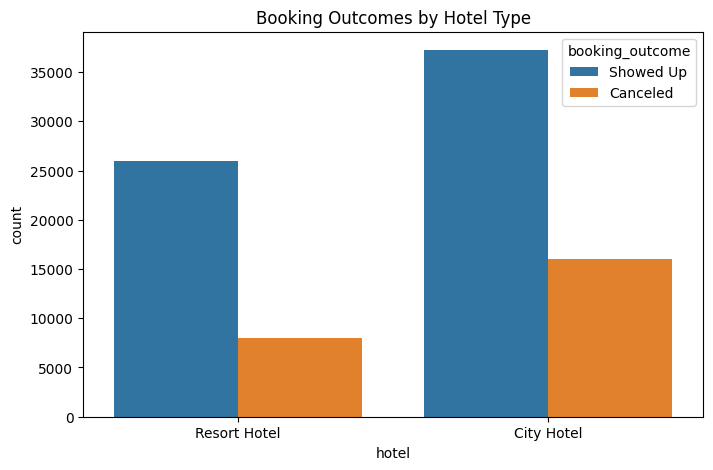

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=new_df,
    x='hotel',
    hue='booking_outcome',
)

plt.title('Booking Outcomes by Hotel Type')
plt.show()

**Insight: The ratio of showed up to canceled is similar in both hotels, with most customers showing up after booking**

## 2.5 Reserved Room Analysis

**Business Question**
- *Which rooms generate high revenue?*
- *Which rooms are in demand?*

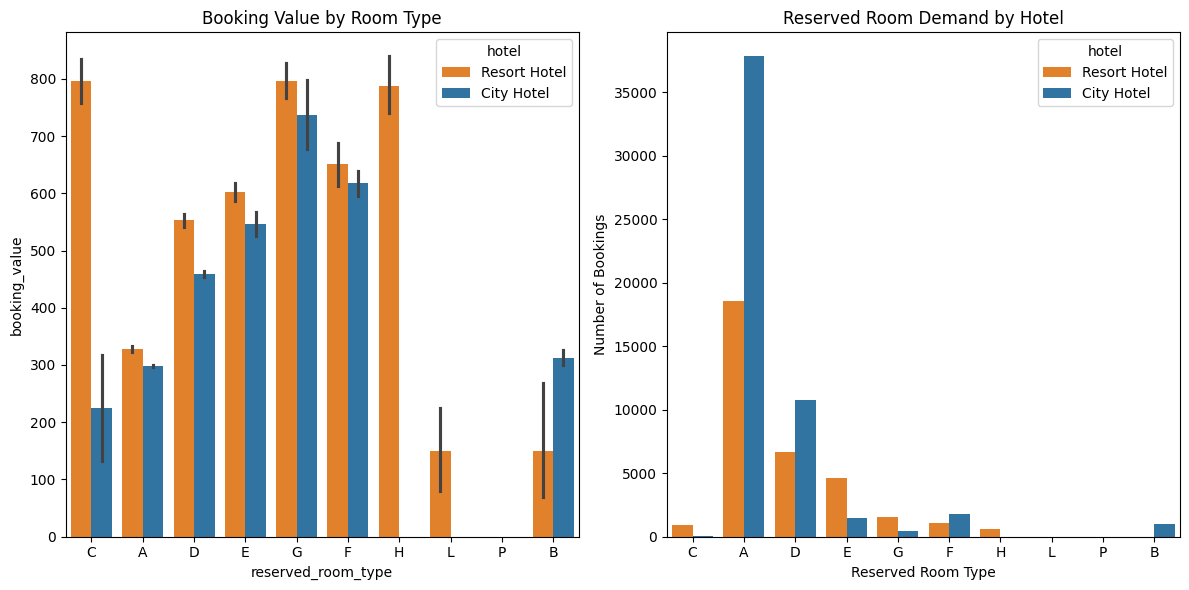

In [70]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.barplot(
    data=new_df,
    x='reserved_room_type',
    y='booking_value',
    hue='hotel',
    palette=hotel_palette
)
plt.title('Booking Value by Room Type')

plt.subplot(1,2,2)
sns.countplot(
    data=new_df,
    x='reserved_room_type',
    hue='hotel',
    palette=hotel_palette
)
plt.title('Reserved Room Demand by Hotel')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

The Resort and City hotels show different booking revenue performance. Whereas the resort hotel shows that rooms H, C, and G have the highest revenue performance, the city hotel shows that rooms G and F have the highest revenue performance.

However, the demand for the reserved rooms tell a different story. Room A has the highest demand across both hotel types, suggesting that the high revenue performance is largely driven by the room prices. This indicates that premium rooms have lower demand than the standard rooms. 

# 3. Understanding Booking Patterns

**Business Questions**
- *Does pricing affect stay duration?*
- *What's the outcome of booking duration?*

## 3.2 Total Nights vs ADR

<Axes: xlabel='total_nights', ylabel='adr'>

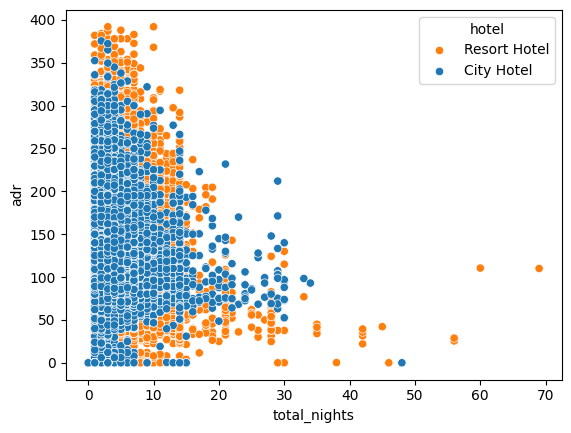

In [52]:
sns.scatterplot(
    data=new_df,
    x='total_nights',
    y='adr',
    hue='hotel',
    palette=hotel_palette
)

**Insight: While the scatter plot seems to suggest that very high ADR bookings were concentrated among shorter stays, the overall relationship is extremely weak. Stay duration alone does not meaningfully explain variation in room pricing.**

## 3.3 Cancellation Status vs Lead Time

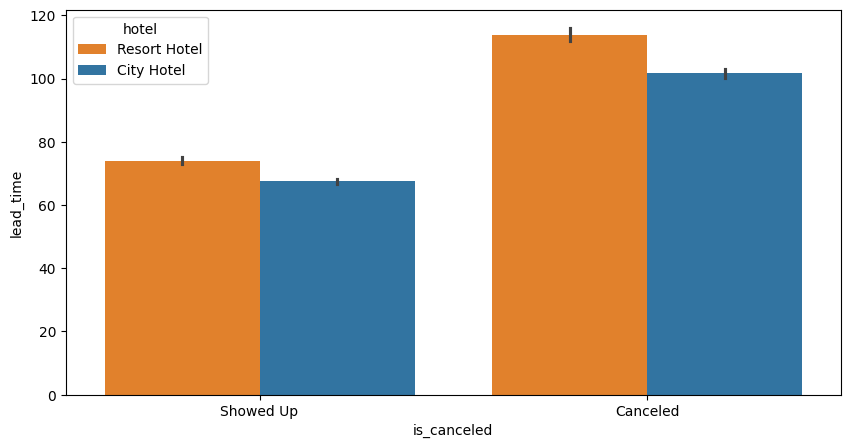

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=new_df,
    x='is_canceled',
    y='lead_time',
    hue='hotel',
    palette=hotel_palette
)
plt.xticks([0,1], ['Showed Up', 'Canceled'])
plt.show()

**Insight: Most booking cancellations are associated with prolonged booking time. Customers probably loose interest or have other emergent activities**

# 4. Correlation Analysis

**Business Question**
- *Which numerical variables are most strongly associated with booking value?*

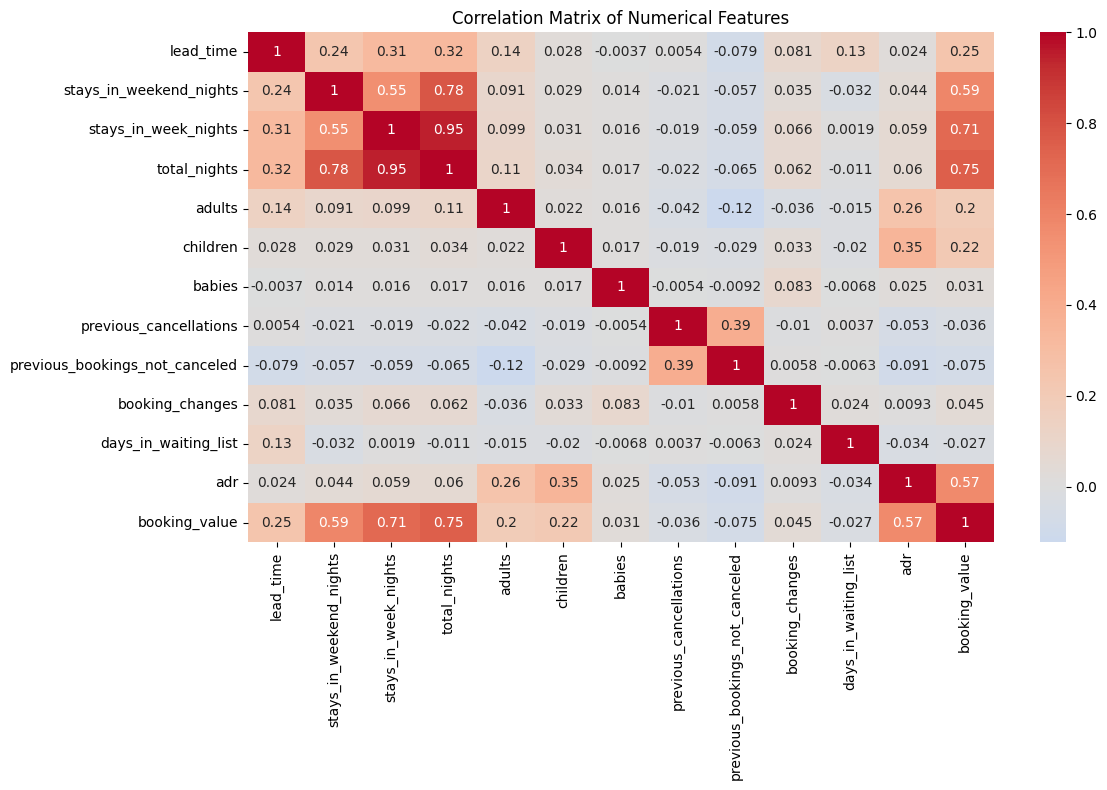

In [64]:
corr_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'total_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'booking_value'
]

corr_matrix = new_df[corr_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [56]:
# Save the updated cleaned dataset
new_df.to_csv(r"C:\Users\ifean\Downloads\TechCrush\hotel_bookings_cleaned-2.csv", index=False)